In [ ]:
!pip install Keras-Preprocessing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import re
import json
import nltk

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SpatialDropout1D, Bidirectional, GlobalMaxPool1D, Conv1D
from tensorflow.keras.utils import to_categorical

import plotly as py
import cufflinks as cf
from plotly.offline import iplot
py.offline.init_notebook_mode(connected=True)
cf.go_offline()

In [ ]:
df=pd.read_csv('/content/15k_Random.csv')

In [ ]:
newdf = df.copy()

In [ ]:
df.head()

,review,sentiment
0,দুই টি দুই কোম্পানির জুতা দিছে,Negative
1,গরম রাখে মাঝে মাঝে অস্বস্তিকর,Neutral
2,"আমি ২টন সাইজের অর্ডার করেছিলাম, সেই সাইজ পেয়ে...",Positive
3,এখন পর্যন্ত ভালো আছে। পরবর্তীতে কেমন সার্ভিস দ...,Negative
4,খুব খারাপ,Negative


In [ ]:
df["sentiment"].unique()

array(['Negative', 'Neutral', 'Positive'], dtype=object)

In [ ]:
df.shape

(15034, 2)

In [ ]:
print("Total Comment:",len(df),
      "\nTotal Negative :",len(df[df.sentiment =='Negative']),
      "\nTotal Positive :",len(df[df.sentiment=='Positive']),
      "\nTotal Neutral :",len(df[df.sentiment=='Neutral']))

Total Comment: 15034 
Total Negative : 5066 
Total Positive : 5147 
Total Neutral : 4821


In [ ]:
import os

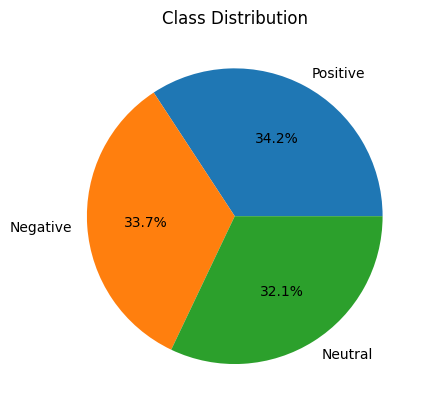

In [ ]:
class_counts = df['sentiment'].value_counts()
class_percents = class_counts / class_counts.sum() * 100
# Plot the pie chart
plt.pie(class_percents, labels=class_counts.index, autopct='%1.1f%%')
plt.title('Class Distribution')
plt.savefig("my_plot.png")
plt.show()

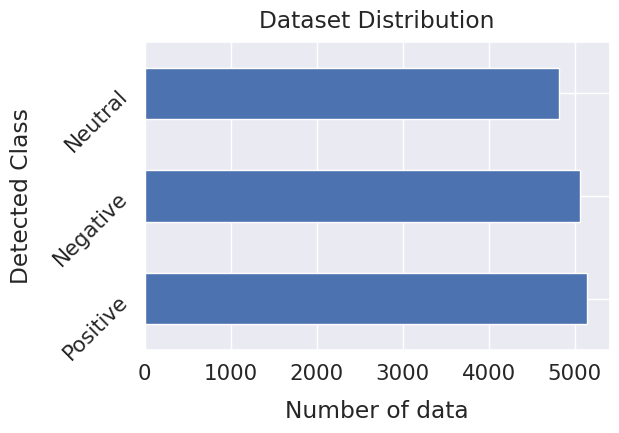

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=1.4)

# Plot
df['sentiment'].value_counts().plot(kind='barh', figsize=(6, 4))
plt.xlabel("Number of data", labelpad=12)
plt.ylabel("Detected Class", labelpad=12)
plt.yticks(rotation=45)
plt.title("Dataset Distribution", y=1.02)

# ✅ Save without cropping
plt.savefig("Dataset Distribution BarChart.png", dpi=300, bbox_inches='tight')

# Optional: Show the plot
plt.show()


In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


# **Data Preprocessing and Cleaning**

In [ ]:
df.drop_duplicates(inplace=True)

# **Stopwords Remove**

In [ ]:
def process_conversations(Conversation):
    stp = open('/content/stopwords-bn (1)(1).txt','r',encoding="utf8").read().split()
    result = Conversation.split()
    Conversation = [word.strip() for word in result if word not in stp ]
    Conversation =" ".join(Conversation)
    Conversation = re.sub('[^\u0980-\u09FF]',' ',str(Conversation))
    return Conversation

In [ ]:
df.dtypes

,0
review,object
sentiment,object


In [ ]:
df['cleaned'] = df['review'].apply(process_conversations)
sample_data = [10,700]
for i in sample_data:
     print('Original:\n',df.review[i],'\nCleaned:\n',
           df.cleaned[i],'\n','Detected as:-- ',df.sentiment[i],'\n')

Original:
 অর্ডার দিলাম ট্রান্সপারেন্ট কেস
পাঠানো হইসে সিলিকন কমদামি ব্যাটম্যান কেস 
Cleaned:
 অর্ডার দিলাম ট্রান্সপারেন্ট কেস পাঠানো হইসে সিলিকন কমদামি ব্যাটম্যান কেস 
 Detected as:--  Negative 

Original:
 ছোটদের বেল বুঝতে পারিনি আর মানিব্যাগটা ভিতরে একটু সমস্যা আছে মানিব্যাগটা মোটামুটি চলে 
Cleaned:
 ছোটদের বেল বুঝতে পারিনি মানিব্যাগটা ভিতরে একটু সমস্যা মানিব্যাগটা মোটামুটি 
 Detected as:--  Negative 



In [ ]:
df

,review,sentiment,cleaned
0,দুই টি দুই কোম্পানির জুতা দিছে,Negative,কোম্পানির জুতা দিছে
1,গরম রাখে মাঝে মাঝে অস্বস্তিকর,Neutral,গরম রাখে মাঝে মাঝে অস্বস্তিকর
2,"আমি ২টন সাইজের অর্ডার করেছিলাম, সেই সাইজ পেয়ে...",Positive,২টন সাইজের অর্ডার করেছিলাম সাইজ পেয়েছি এসি...
3,এখন পর্যন্ত ভালো আছে। পরবর্তীতে কেমন সার্ভিস দ...,Negative,ভালো আছে পরবর্তীতে কেমন সার্ভিস দেয় আসল বিষয় ...
4,খুব খারাপ,Negative,খারাপ
...,...,...,...
15029,অনেক ভালো পন্যটি ধন্যবাদ দারাজকে।,Positive,ভালো পন্যটি ধন্যবাদ দারাজকে
15030,সেই জিনিস মাল একটুও পোড়ে না,Negative,জিনিস মাল একটুও পোড়ে
15031,শিশুর ভাষা শিখতে সাহায্য করে কিন্তু শব্দভাণ্ডা...,Neutral,শিশুর ভাষা শিখতে সাহায্য শব্দভাণ্ডার সীমিত
15032,ভালো ১০০%,Positive,ভালো ১০০


# **Small Text Remove**

In [ ]:
df['length'] = df['cleaned'].apply(lambda x:len(x.split()))

dataset = df.loc[df.length>0]
dataset = dataset.reset_index(drop = True)
print("After Cleaning:","\nRemoved {} Small conversations".format(len(df)-len(dataset)),
      "\nTotal conversations:",len(dataset))

dataset['no_char'] = df['cleaned'].apply(lambda cleaned: len(cleaned))

After Cleaning: 
Removed 12 Small conversations 
Total conversations: 15014


In [ ]:
dataset

,review,sentiment,cleaned,length,no_char
0,দুই টি দুই কোম্পানির জুতা দিছে,Negative,কোম্পানির জুতা দিছে,3,19.0
1,গরম রাখে মাঝে মাঝে অস্বস্তিকর,Neutral,গরম রাখে মাঝে মাঝে অস্বস্তিকর,5,29.0
2,"আমি ২টন সাইজের অর্ডার করেছিলাম, সেই সাইজ পেয়ে...",Positive,২টন সাইজের অর্ডার করেছিলাম সাইজ পেয়েছি এসি...,29,184.0
3,এখন পর্যন্ত ভালো আছে। পরবর্তীতে কেমন সার্ভিস দ...,Negative,ভালো আছে পরবর্তীতে কেমন সার্ভিস দেয় আসল বিষয় ...,14,77.0
4,খুব খারাপ,Negative,খারাপ,1,5.0
...,...,...,...,...,...
15009,অনেক ভালো পন্যটি ধন্যবাদ দারাজকে।,Positive,ভালো পন্যটি ধন্যবাদ দারাজকে,4,137.0
15010,সেই জিনিস মাল একটুও পোড়ে না,Negative,জিনিস মাল একটুও পোড়ে,4,55.0
15011,শিশুর ভাষা শিখতে সাহায্য করে কিন্তু শব্দভাণ্ডা...,Neutral,শিশুর ভাষা শিখতে সাহায্য শব্দভাণ্ডার সীমিত,6,19.0
15012,ভালো ১০০%,Positive,ভালো ১০০,2,18.0


# **Stemming**

In [ ]:
!pip install bangla-stemmer
from bangla_stemmer.stemmer import stemmer
## stemmer function
def stem_text (x):
  stmr = stemmer.BanglaStemmer()
  words=x.split(' ')
  stm = stmr.stem(words)
  words=(' ').join(stm)
  return words

In [ ]:
dataset.head()

,review,sentiment,cleaned,length,no_char
0,দুই টি দুই কোম্পানির জুতা দিছে,Negative,কোম্পানির জুতা দিছে,3,19.0
1,গরম রাখে মাঝে মাঝে অস্বস্তিকর,Neutral,গরম রাখে মাঝে মাঝে অস্বস্তিকর,5,29.0
2,"আমি ২টন সাইজের অর্ডার করেছিলাম, সেই সাইজ পেয়ে...",Positive,২টন সাইজের অর্ডার করেছিলাম সাইজ পেয়েছি এসি...,29,184.0
3,এখন পর্যন্ত ভালো আছে। পরবর্তীতে কেমন সার্ভিস দ...,Negative,ভালো আছে পরবর্তীতে কেমন সার্ভিস দেয় আসল বিষয় ...,14,77.0
4,খুব খারাপ,Negative,খারাপ,1,5.0


In [ ]:
dataset['stemming']=dataset['cleaned'].apply(stem_text)

Streaming output truncated to the last 5000 lines.
applied fourth rules..
applied first rules..
applied fourth rules..
applied first rules..
applied second rules..
applied fourth rules..
applied first rules..
applied fourth rules..
applied fourth rules..
applied fourth rules..
applied fourth rules..
applied fourth rules..
applied fourth rules..
applied second rules..
applied fourth rules..
applied second rules..
applied fourth rules..
applied fourth rules..
applied first rules..
applied fourth rules..
applied first rules..
applied first rules..
applied fourth rules..
applied first rules..
applied fourth rules..
applied second rules..
applied fourth rules..
applied first rules..
applied fourth rules..
applied fourth rules..
applied fourth rules..
applied second rules..
applied fourth rules..
applied fourth rules..
applied second rules..
applied fourth rules..
applied fourth rules..
applied fourth rules..
applied first rules..
applied fourth rules..
applied second rules..
applied first r

In [ ]:
dataset

,review,sentiment,cleaned,length,no_char,stemming
0,দুই টি দুই কোম্পানির জুতা দিছে,Negative,কোম্পানির জুতা দিছে,3,19.0,কোম্পানির জুতা দিছ
1,গরম রাখে মাঝে মাঝে অস্বস্তিকর,Neutral,গরম রাখে মাঝে মাঝে অস্বস্তিকর,5,29.0,গরম রাখে মাঝে মাঝে অস্বস্তিকর
2,"আমি ২টন সাইজের অর্ডার করেছিলাম, সেই সাইজ পেয়ে...",Positive,২টন সাইজের অর্ডার করেছিলাম সাইজ পেয়েছি এসি...,29,184.0,২টন সাইজ অর্ড করেছি সাইজ পেয়ে এসির সাইজ ১ ...
3,এখন পর্যন্ত ভালো আছে। পরবর্তীতে কেমন সার্ভিস দ...,Negative,ভালো আছে পরবর্তীতে কেমন সার্ভিস দেয় আসল বিষয় ...,14,77.0,ভালো আছ পরবর্তী কেমন সার্ভ দেয় আসল বিষয় আশা ...
4,খুব খারাপ,Negative,খারাপ,1,5.0,খারাপ
...,...,...,...,...,...,...
15009,অনেক ভালো পন্যটি ধন্যবাদ দারাজকে।,Positive,ভালো পন্যটি ধন্যবাদ দারাজকে,4,137.0,ভালো পন্য ধন্যবাদ দারাজ
15010,সেই জিনিস মাল একটুও পোড়ে না,Negative,জিনিস মাল একটুও পোড়ে,4,55.0,জিন মাল একটু পোড়ে
15011,শিশুর ভাষা শিখতে সাহায্য করে কিন্তু শব্দভাণ্ডা...,Neutral,শিশুর ভাষা শিখতে সাহায্য শব্দভাণ্ডার সীমিত,6,19.0,শিশুর ভাষা শিখ সাহায্য শব্দভাণ্ড সীমিত
15012,ভালো ১০০%,Positive,ভালো ১০০,2,18.0,ভালো ১০০


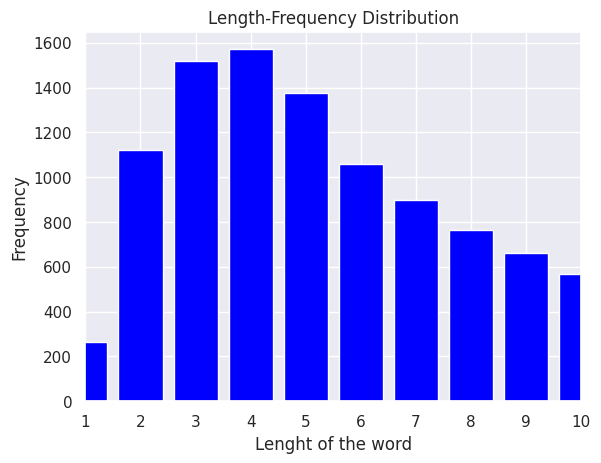

Maximum Length of a comment: 139
Minimum Length of a comment: 1
Average Length of a comment: 10.0


In [ ]:
frequency = dict()
for i in dataset.length:
    frequency[i] = frequency.get(i, 0)+1

plt.bar(frequency.keys(), frequency.values(), color ="blue")
plt.xlim(1, 10)

plt.xlabel('Lenght of the word')
plt.ylabel('Frequency')
plt.title('Length-Frequency Distribution')
plt.show()
print(f"Maximum Length of a comment: {max(dataset.length)}")
print(f"Minimum Length of a comment: {min(dataset.length)}")
print(f"Average Length of a comment: {round(np.mean(dataset.length),0)}")

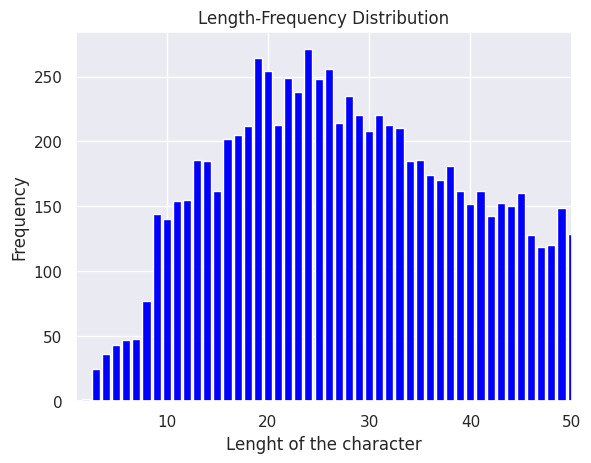

Maximum Length of a comment: 833.0
Minimum Length of a comment: 0.0
Average Length of a comment: 66.0


<Figure size 640x480 with 0 Axes>

In [ ]:
frequency = dict()
for i in dataset.no_char:
    frequency[i] = frequency.get(i, 0)+1

plt.bar(frequency.keys(), frequency.values(), color ="blue")
plt.xlim(1, 50)

plt.xlabel('Lenght of the character')
plt.ylabel('Frequency')
plt.title('Length-Frequency Distribution')
plt.show()
print(f"Maximum Length of a comment: {max(dataset.no_char)}")
print(f"Minimum Length of a comment: {min(dataset.no_char)}")
print(f"Average Length of a comment: {round(np.mean(dataset.no_char),0)}")
plt.savefig("Character Frequency Distribution Bangla BarChart.png")

# **Dataset Summary**

In [ ]:
def data_summary(dataset):
    documents = []
    words = []
    most_frequent_word =[]
    u_words = []

    total_u_words = [word.strip().lower() for t in list(dataset.cleaned) for word in t.strip().split()]
    class_label= [k for k,v in dataset.sentiment.value_counts().to_dict().items()]

    for label in class_label:
        word_list = [word.strip().lower() for t in list(dataset[dataset.sentiment==label].cleaned) for word in t.strip().split()]

        counts = dict()

        for word in word_list:
                counts[word] = counts.get(word, 0)+1

        ordered = sorted(counts.items(), key= lambda item: item[1],reverse = True)

        documents.append(len(list(dataset[dataset.sentiment==label].cleaned)))

        words.append(len(word_list))

        u_words.append(len(np.unique(word_list)))

        print("\nClass Name : ",label)
        print("Number of comments:{}".format(len(list(dataset[dataset.sentiment==label].cleaned))))
        print("Number of Words:{}".format(len(word_list)))
        print("Number of Unique Words:{}".format(len(np.unique(word_list))))
        print("Most Frequent Words:\n")
        for k,v in ordered[:15]:
              print("{}\t{}".format(k,v))
    print("Total Number of Unique Words:{}".format(len(np.unique(total_u_words))))

    return documents,words,u_words,class_label

documents,words,u_words,class_names = data_summary(dataset)


Class Name :  Positive
Number of comments:5144
Number of Words:63250
Number of Unique Words:7049
Most Frequent Words:

ভালো	4328
ধন্যবাদ	2214
আলহামদুলিল্লাহ	1508
সুন্দর	1292
প্রোডাক্ট	1176
সেলার	993
ডেলিভারি	803
পেয়েছি	802
দারাজ	779
পেয়েছি	709
পারেন	658
আপনারা	642
চাইলে	626
একটা	619
টা	576

Class Name :  Negative
Number of comments:5055
Number of Words:53555
Number of Unique Words:8775
Most Frequent Words:

না	1034
একটা	973
বাজে	954
ভালো	946
অর্ডার	709
প্রোডাক্ট	586
টা	566
কালার	491
টাকা	482
খারাপ	476
একদম	409
দিছে	367
জিনিস	364
সাথে	363
খুবই	362

Class Name :  Neutral
Number of comments:4815
Number of Words:38149
Number of Unique Words:7126
Most Frequent Words:

ভালো	1794
মোটামুটি	874
দাম	553
একটু	464
না	433
কিছুটা	299
কম	292
খারাপ	290
টা	287
প্রোডাক্ট	247
ভালোই	230
একটা	227
ছোট	225
ডেলিভারি	217
মান	199
Total Number of Unique Words:15500


In [ ]:
data_matrix = pd.DataFrame({'Total comments':documents,
                            'Total Words':words,
                            'Unique Words':u_words,
                            'Class Names':class_names})
data = pd.melt(data_matrix, id_vars="Class Names", var_name="Category", value_name="Values")

In [ ]:
data

,Class Names,Category,Values
0,Positive,Total comments,5144
1,Negative,Total comments,5055
2,Neutral,Total comments,4815
3,Positive,Total Words,63250
4,Negative,Total Words,53555
5,Neutral,Total Words,38149
6,Positive,Unique Words,7049
7,Negative,Unique Words,8775
8,Neutral,Unique Words,7126


# **Data Summary Visualization**

/tmp/ipython-input-1337874303.py:8: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



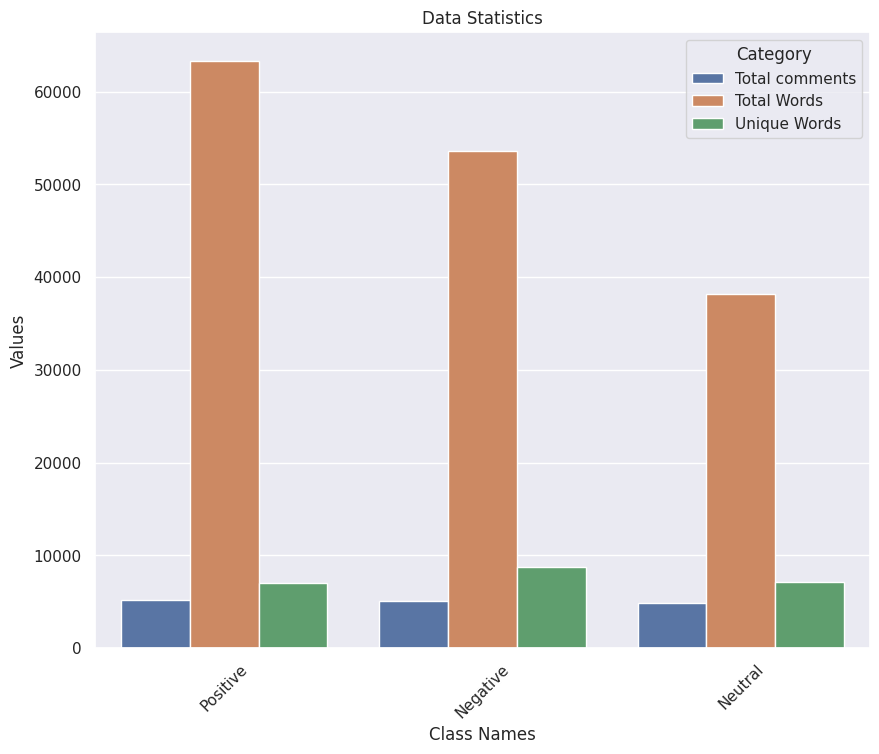

In [ ]:
plt.figure(figsize=(10, 8))
ax = plt.subplot()

sns.barplot(data=data,x='Class Names', y='Values' ,hue='Category')
ax.set_xlabel('Class Names')
ax.set_title('Data Statistics')

ax.xaxis.set_ticklabels(class_names, rotation=45);

plt.savefig("Data Statistics Bangla BarChart.png")

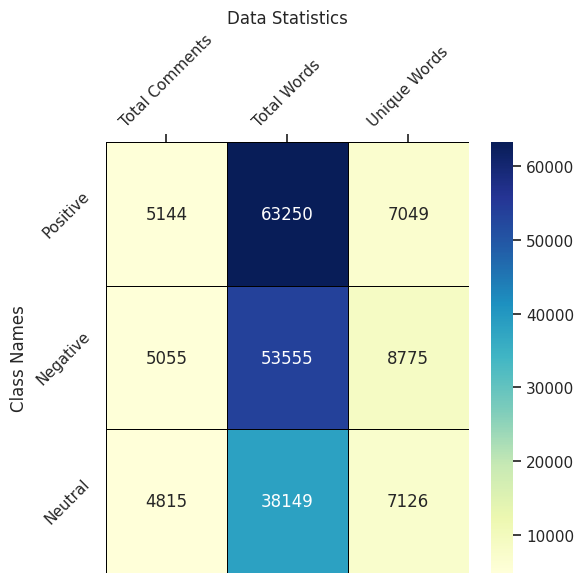

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()
plt.figure(figsize=(6, 6))
ax = plt.subplot()

# Create the heatmap
sns.heatmap(
    data_matrix.iloc[:, 0:3],
    annot=True,
    fmt="d",
    linewidths=0.5,
    linecolor='Black',
    cmap="YlGnBu",
    ax=ax
)

# Set labels and titles
ax.set_ylabel('Class Names')
ax.set_title('Data Statistics')

# Set custom tick labels
y_label = ["Total Comments", "Total Words", "Unique Words"]
ax.xaxis.set_ticklabels(y_label, rotation=45)
ax.yaxis.set_ticklabels(class_names, rotation=45)
ax.xaxis.tick_top()

# ✅ Adjust layout and save without cropping
plt.tight_layout()
plt.savefig("Data Statistics Bangla.png", dpi=300, bbox_inches='tight')

# Optional: show the plot
plt.show()


In [ ]:
def label_encoding(sentiment,bool):

    le = LabelEncoder()
    le.fit(sentiment)
    encoded_labels = le.transform(sentiment)
    labels = np.array(encoded_labels)
    class_names =le.classes_
    if bool == True:
        print("\n\t\t\t===== Label Encoding =====","\nClass Names:-->",le.classes_)
        for i in sample_data:
            print(sentiment[i],' ', encoded_labels[i],'\n')

    return labels

In [ ]:
def dataset_split(feature_space,sentiment):

    X_train,X_test,y_train,y_test = train_test_split(feature_space,sentiment,train_size = 0.8,
                                                  test_size = 0.2,random_state =0)
    print("Feature Size :======>",X_train.shape[1])
    print("\nDataset Distribution:\n")
    print("\tSet Name","\t\tSize")
    print("\t========\t\t======")

    print("\tFull\t\t\t",feature_space.shape[0],
        "\n\tTraining\t\t",X_train.shape[0],
        "\n\tTest\t\t\t",X_test.shape[0])

    return X_train,X_test,y_train,y_test

In [ ]:
dataset.cleaned = dataset.stemming.apply(lambda x:x.replace('\n',' '))

In [ ]:
dataset

,review,sentiment,cleaned,length,no_char,stemming
0,দুই টি দুই কোম্পানির জুতা দিছে,Negative,কোম্পানির জুতা দিছ,3,19.0,কোম্পানির জুতা দিছ
1,গরম রাখে মাঝে মাঝে অস্বস্তিকর,Neutral,গরম রাখে মাঝে মাঝে অস্বস্তিকর,5,29.0,গরম রাখে মাঝে মাঝে অস্বস্তিকর
2,"আমি ২টন সাইজের অর্ডার করেছিলাম, সেই সাইজ পেয়ে...",Positive,২টন সাইজ অর্ড করেছি সাইজ পেয়ে এসির সাইজ ১ ...,29,184.0,২টন সাইজ অর্ড করেছি সাইজ পেয়ে এসির সাইজ ১ ...
3,এখন পর্যন্ত ভালো আছে। পরবর্তীতে কেমন সার্ভিস দ...,Negative,ভালো আছ পরবর্তী কেমন সার্ভ দেয় আসল বিষয় আশা ...,14,77.0,ভালো আছ পরবর্তী কেমন সার্ভ দেয় আসল বিষয় আশা ...
4,খুব খারাপ,Negative,খারাপ,1,5.0,খারাপ
...,...,...,...,...,...,...
15009,অনেক ভালো পন্যটি ধন্যবাদ দারাজকে।,Positive,ভালো পন্য ধন্যবাদ দারাজ,4,137.0,ভালো পন্য ধন্যবাদ দারাজ
15010,সেই জিনিস মাল একটুও পোড়ে না,Negative,জিন মাল একটু পোড়ে,4,55.0,জিন মাল একটু পোড়ে
15011,শিশুর ভাষা শিখতে সাহায্য করে কিন্তু শব্দভাণ্ডা...,Neutral,শিশুর ভাষা শিখ সাহায্য শব্দভাণ্ড সীমিত,6,19.0,শিশুর ভাষা শিখ সাহায্য শব্দভাণ্ড সীমিত
15012,ভালো ১০০%,Positive,ভালো ১০০,2,18.0,ভালো ১০০


In [ ]:
dataset=dataset.drop(["review","cleaned","length","no_char"],axis=1)

In [ ]:
dataset.head()

,sentiment,stemming
0,Negative,কোম্পানির জুতা দিছ
1,Neutral,গরম রাখে মাঝে মাঝে অস্বস্তিকর
2,Positive,২টন সাইজ অর্ড করেছি সাইজ পেয়ে এসির সাইজ ১ ...
3,Negative,ভালো আছ পরবর্তী কেমন সার্ভ দেয় আসল বিষয় আশা ...
4,Negative,খারাপ


# **Unigram Tf-idf value calculation**

In [ ]:
def calc_gram_tfidf(Conversations):
    tfidf = TfidfVectorizer(ngram_range=(1,3),use_idf=True,tokenizer=lambda x: x.split())
    X = tfidf.fit_transform(Conversations)

    return tfidf,X

# **Unigram**

In [ ]:
x = ["ঠিকঠাক ছিল  সেলার ভাই আচরণ ভালো ছিল  ফাস্ট চার্জ চার্জার কিছুটা গরম হয়"]

def get_top_n_words(x, n):
    vec = CountVectorizer().fit(x)
    bow = vec.transform(x)
    sum_words = bow.sum(axis = 0)
    words_freq = [(word, sum_words[0,idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse = True)
    return words_freq[:n]

get_top_n_words(x,3)

[('কঠ', np.int64(1)), ('আচরণ', np.int64(1)), ('গরম', np.int64(1))]

# **Bigram**

In [ ]:
y = ["ঠিকঠাক ছিল  সেলার ভাই আচরণ ভালো ছিল  ফাস্ট চার্জ চার্জার কিছুটা গরম হয়"]
def get_top_n_words(x, n):
    vec = CountVectorizer(ngram_range=(2, 2)).fit(x)
    bow = vec.transform(x)
    sum_words = bow.sum(axis = 0)
    words_freq = [(word, sum_words[0,idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse = True)
    return words_freq[:n]
get_top_n_words(y,3)

[('কঠ আচরণ', np.int64(1)), ('আচরণ গরম', np.int64(1)), ('গরম হয', np.int64(1))]

# **Trigram**

In [ ]:
z = ["ঠিকঠাক ছিল  সেলার ভাই আচরণ ভালো ছিল  ফাস্ট চার্জ চার্জার কিছুটা গরম হয়"]
def get_top_n_words(x, n):
    vec = CountVectorizer(ngram_range=(3, 3)).fit(x)
    bow = vec.transform(x)
    sum_words = bow.sum(axis = 0)
    words_freq = [(word, sum_words[0,idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse = True)
    return words_freq[:n]
get_top_n_words(z,3)

[('কঠ আচরণ গরম', np.int64(1)), ('আচরণ গরম হয', np.int64(1))]

In [ ]:
import warnings
warnings.filterwarnings("ignore")


# gram_names = ['Unigram','Bigram','Trigram']
# ngrams = [(1,1),(1,2),(1,3)]

# for i,gram in enumerate(ngrams):
#      tfidf,feature = calc_gram_tfidf(dataset.stemming)
#      labels = label_encoding(dataset.sentiment,False)
#      X_train,X_test,y_train,y_test = dataset_split(feature,labels)
#      ml_models,model_names = ml_models_defination()
#      accuracy = {f'{model_names[j]}': model_performance(model, X_train, X_test, y_train, y_test) for j, model in enumerate(ml_models)}

#      with open(f'ml_performance_{gram_names[i]}.json', 'w') as f:
#            json.dump(accuracy,f)

# **Tokenization**

In [ ]:
max_features = 2500
tokenizer = Tokenizer(num_words=max_features, split=' ')
tokenizer.fit_on_texts(dataset['stemming'].values)
X = tokenizer.texts_to_sequences(dataset['stemming'].values)
X = pad_sequences(X)

In [ ]:
X

array([[   0,    0,    0, ..., 1368,  100,   41],
       [   0,    0,    0, ...,  209,  209, 1226],
       [   0,    0,    0, ...,   13,   29,    3],
       ...,
       [   0,    0,    0, ..., 1187,  809,  418],
       [   0,    0,    0, ...,    0,    1,  123],
       [   0,    0,    0, ...,    1,  105,   67]], dtype=int32)

In [ ]:
np.shape(X)

(15014, 117)

# **Model Implementation**

In [ ]:
X.shape

(15014, 117)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Bidirectional, Dropout
from tensorflow.keras.layers import Conv1D, MaxPooling1D

embed_dim = 64
filters = 128
kernel_size = 5

model = Sequential()
model.add(Embedding(max_features, embed_dim, input_length=X.shape[1]))
model.add(Conv1D(filters, kernel_size, activation='relu'))
model.add(MaxPooling1D())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.build(input_shape=(None, X.shape[1]))
model.summary()

NameError: name 'X' is not defined

In [ ]:
Y = pd.get_dummies(dataset['sentiment']).values
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2,random_state = 42)
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(12011, 117) (12011, 3)
(3003, 117) (3003, 3)


In [ ]:
history=model.fit(X_train, Y_train, epochs = 50, batch_size=32, verbose = 1,validation_data=(X_test,Y_test))

Epoch 1/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 85s 198ms/step - accuracy: 0.5903 - loss: 0.8406 - val_accuracy: 0.7919 - val_loss: 0.5235
Epoch 2/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 72s 192ms/step - accuracy: 0.8311 - loss: 0.4249 - val_accuracy: 0.7882 - val_loss: 0.5308
Epoch 3/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 84s 196ms/step - accuracy: 0.8671 - loss: 0.3426 - val_accuracy: 0.7859 - val_loss: 0.5654
Epoch 4/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 74s 196ms/step - accuracy: 0.8918 - loss: 0.2882 - val_accuracy: 0.7789 - val_loss: 0.5852
Epoch 5/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 83s 199ms/step - accuracy: 0.9012 - loss: 0.2527 - val_accuracy: 0.7732 - val_loss: 0.6769
Epoch 6/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 82s 199ms/step - accuracy: 0.9189 - loss: 0.2145 - val_accuracy: 0.7649 - val_loss: 0.7722
Epoch 7/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 80s 192ms/step - accuracy: 0.9305 - loss: 0.1768 - val_accuracy: 0.7639 - val_loss: 0.8897
Epoch 8/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 81s 191ms/step - accuracy: 0.9397 - loss: 0

In [ ]:
import tensorflow as tf

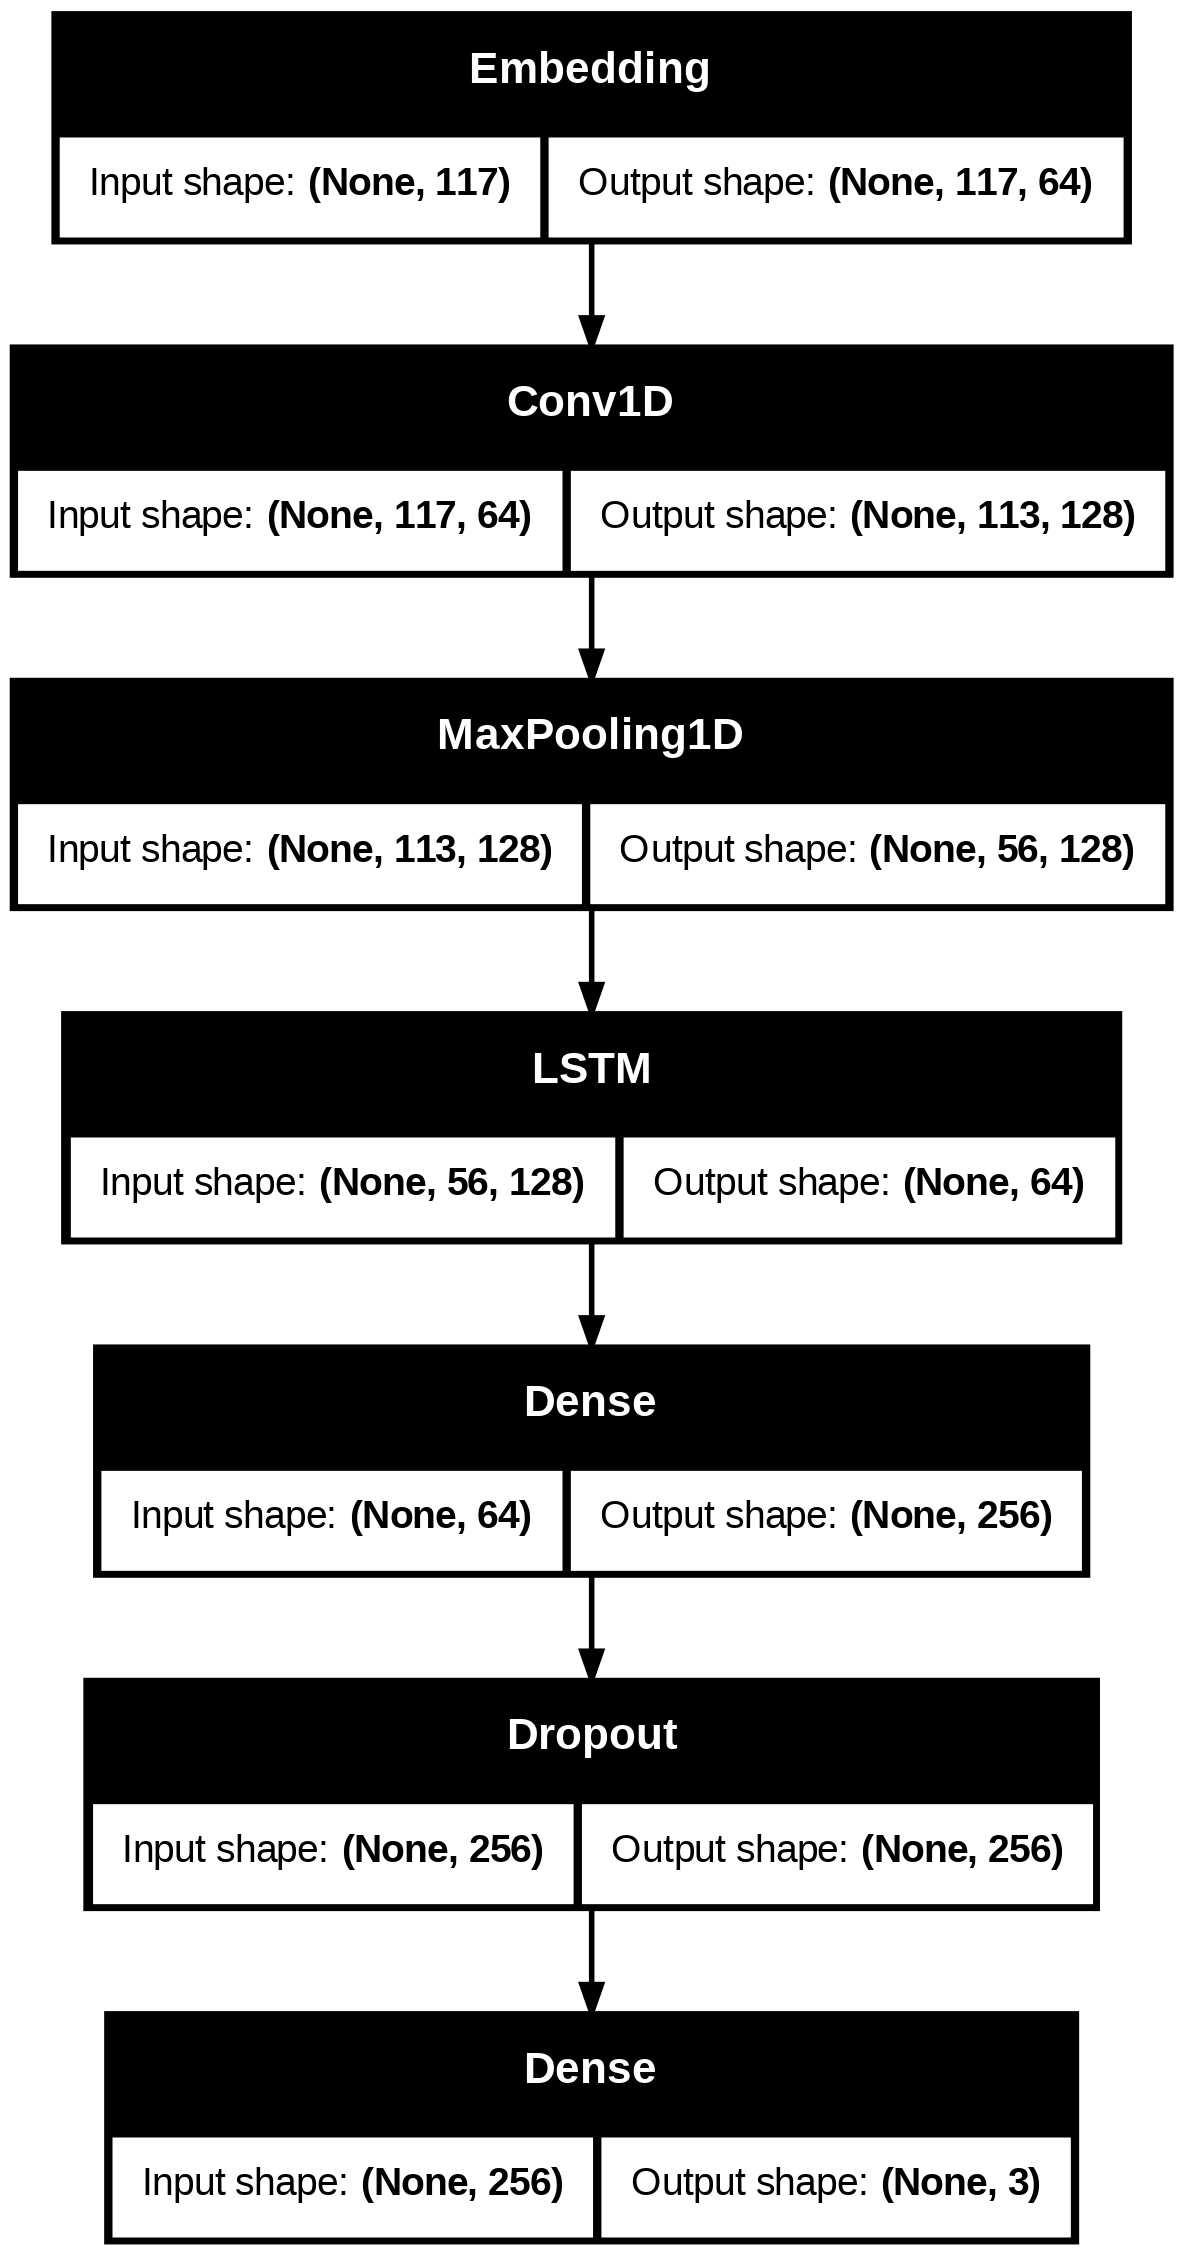

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

# **Evaluation**

In [ ]:
score = model.evaluate(X_train, Y_train,batch_size=64, verbose=2)
print('Train loss:', score[0])
print('Train accuracy:', score[1])

188/188 - 6s - 32ms/step - accuracy: 0.9623 - loss: 0.0799
Train loss: 0.07989156246185303
Train accuracy: 0.9622845649719238


In [ ]:
score = model.evaluate(X_test, Y_test,batch_size=64, verbose=2)
print('Test loss:', score[0])
acc=score[1]
print('Test accuracy:', acc)

47/47 - 2s - 33ms/step - accuracy: 0.7602 - loss: 2.1118
Test loss: 2.1118032932281494
Test accuracy: 0.7602397799491882


# **Learning Curve**

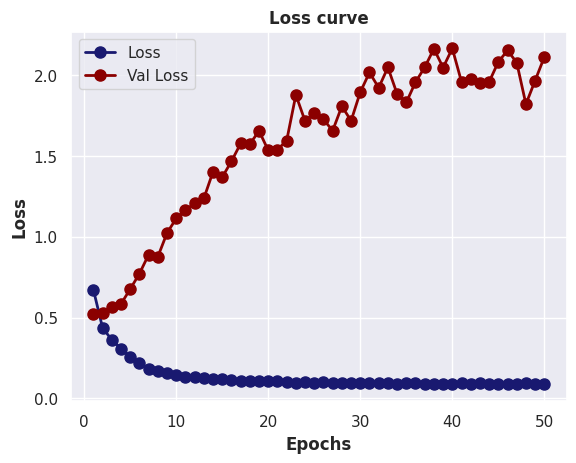

In [ ]:
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)
sns.set_style('darkgrid')


plt.plot(epochs, loss_values, color='midnightblue', linewidth = 2,
          marker='o', markersize=8,label='Training Accuracy')
plt.plot(epochs, val_loss_values, color='darkred', linewidth = 2,
          marker='o', markersize=8,label='Training Accuracy')
plt.title('Loss curve',fontsize=12,fontweight='bold')
plt.xlabel('Epochs',fontsize=12,fontweight='bold')
plt.ylabel('Loss',fontsize=12,fontweight='bold')
plt.legend(['Loss','Val Loss'])

In [ ]:
plt.plot(epochs, acc, color='midnightblue', linewidth = 2,
          marker='o', markersize=8,label='Training Accuracy')
plt.plot(epochs, val_acc, color='darkred', linewidth = 2,
          marker='o', markersize=8,label='Training Accuracy')
plt.title('Training and validation accuracy',fontsize=12,fontweight='bold')
plt.xlabel('Epochs',fontsize=12,fontweight='bold')
plt.ylabel('Accuracy',fontsize=12,fontweight='bold')
plt.legend(['Training Accuracy','Validation Accuracy'])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


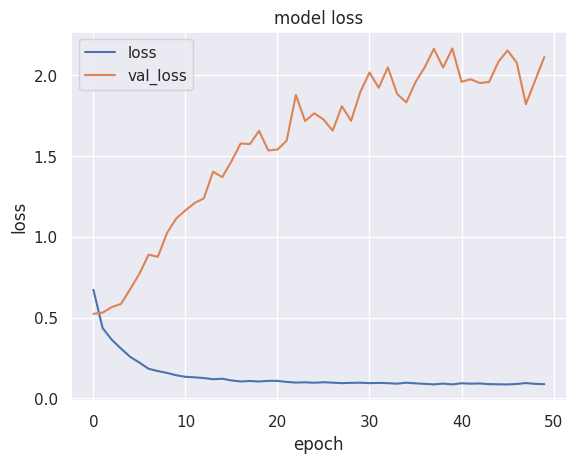

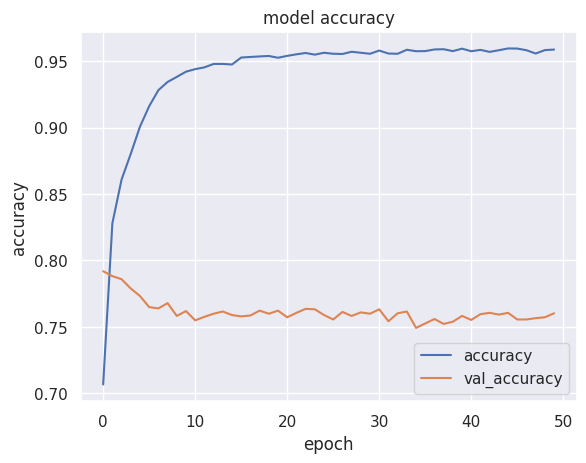

In [ ]:
print(history.history.keys())
loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(loss)
plt.plot(val_loss)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss', 'val_loss'])
plt.show()

accuracy = history.history['accuracy']
val_accuracy= history.history['val_accuracy']
plt.plot(accuracy)
plt.plot(val_accuracy)
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['accuracy', 'val_accuracy'])
plt.show()

# **Confusion Matrix & Classification Report**

In [ ]:
X_train.shape,Y_train.shape,X_test.shape,Y_test.shape

((12011, 117), (12011, 3), (3003, 117), (3003, 3))

In [ ]:
y_pred=model.predict(X_test)
y_pred=np.argmax(y_pred, axis=1)
y_test=np.argmax(Y_test, axis=1)
cm = confusion_matrix(y_test, y_pred)
print(cm)

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step
[[768 184  79]
 [166 681 114]
 [ 73 104 834]]


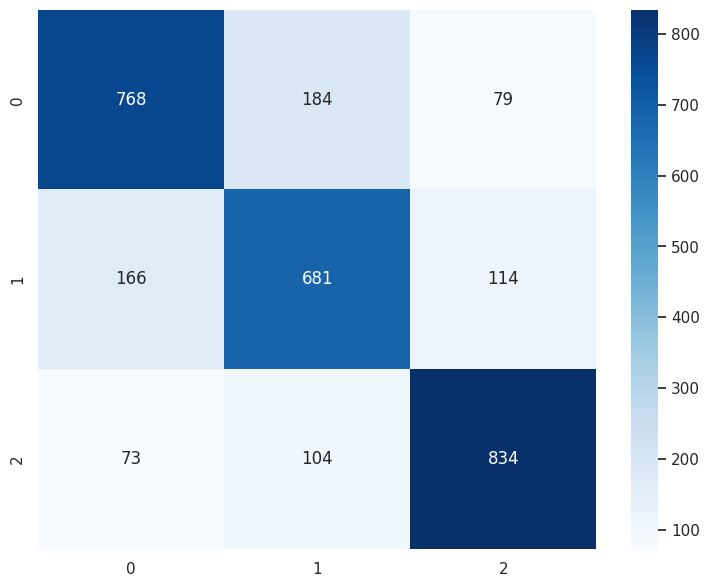

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm,cmap='Blues', annot=True,fmt='d')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
report = pd.DataFrame(classification_report(y_test, y_pred,output_dict=True)).transpose()

In [ ]:
report = report.rename(index={'0': 'Positive','1':'Negative','2':'Neutral'})
report[['precision','recall','f1-score']]=report[['precision','recall','f1-score']].apply(lambda x: round(x*100,2))

In [ ]:
report

,precision,recall,f1-score,support
Positive,76.27,74.49,75.37,1031.00000
Negative,70.28,70.86,70.57,961.00000
Neutral,81.21,82.49,81.84,1011.00000
accuracy,76.02,76.02,76.02,0.76024
macro avg,75.92,75.95,75.93,3003.00000
weighted avg,76.01,76.02,76.01,3003.00000


# **Output Analysing**

In [ ]:
twt = ['ছবিতে যেটা আছে সেটা পাইনি']
twt = tokenizer.texts_to_sequences(twt)
twt = pad_sequences(twt, maxlen=28, dtype='int32', value=0)
print(twt)
sentiment = model.predict(twt,batch_size=1,verbose = 2)[0]
if(np.argmax(sentiment) == 0):
    print("negative")
elif (np.argmax(sentiment) == 1):
    print("Positive")

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0  83 662 154]]
1/1 - 1s - 657ms/step
negative
